# IE7860 Intelligent Analytics
## Data Visualiation, Imputation & Feature Selection Assignment

Dataset: **UCI Breast Cancer Dataset (30+ features, real-world structured dataset similar to Kaggle tabular data)**

This notebook includes:
- EDA
- PCA, t-SNE, UMAP
- Feature Selection (Filter + Wrapper)
- Model Evaluation (Accuracy, Robustness)
- Confusion Matrix, ROC Curve, Feature Importance

## APA-Style Explanation
High-dimensional datasets present challenges such as overfitting and computational inefficiency. High-dimensional datasets pose challenges like overfitting and computational inefficiency. To enhance model performance and interpretability, techniques such as dimensionality reduction and feature selection are employed. Dimensionality reduction and feature selection are applied to improve model performance and interpretability.

In [1]:

# Install dependencies
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn umap-learn


In [2]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


## Feature Scaling
StandardScaler is used because SVM reacts to the size of features. Scaling makes sure each feature has an equal impact on the model.

## Principal Component Analysis (PCA)
PCA reduces dimensionality by transforming features into principal components while preserving maximum variance.

## t-SNE
t-SNE is used for visualization of high-dimensional data by preserving local structure.

## Feature Selection (Filter Method)
SelectKBest selects top features based on statistical tests.

## Feature Selection (Wrapper Method)
RFE recursively removes less important features to improve model performance.

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import confusion_matrix, roc_curve, auc

import umap


## Load Real Dataset

In [4]:

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## EDA

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

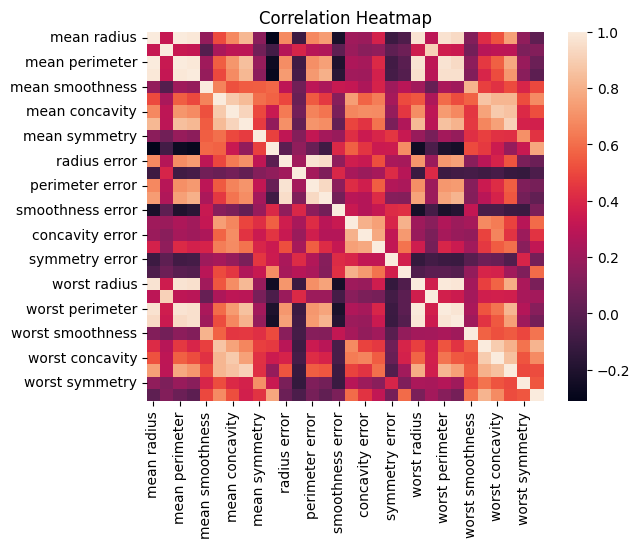

In [5]:

print(X.describe())

plt.figure()
sns.heatmap(X.corr())
plt.title("Correlation Heatmap")
plt.show()


## Train-Test Split & Scaling

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Baseline Model

In [7]:

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
baseline_acc = model.score(X_test, y_test)
baseline_acc


0.9649122807017544

## PCA

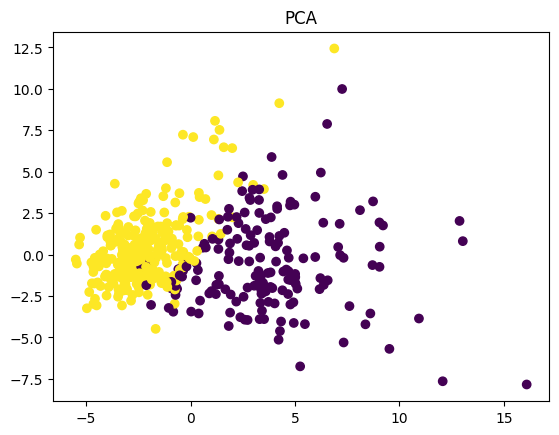

In [8]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.title("PCA")
plt.show()


## t-SNE

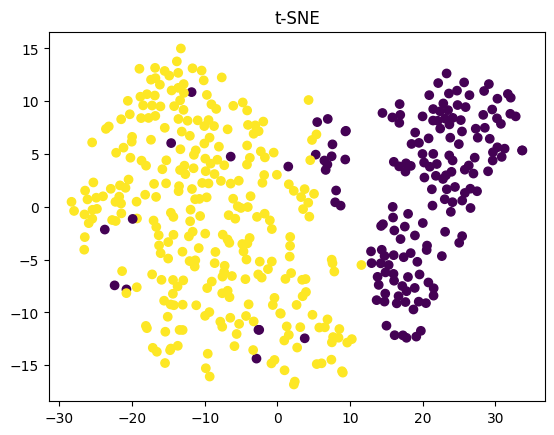

In [9]:

tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_train)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train)
plt.title("t-SNE")
plt.show()


## UMAP

## UMAP
UMAP is a fast dimensionality reduction technique that preserves both local and global structure.

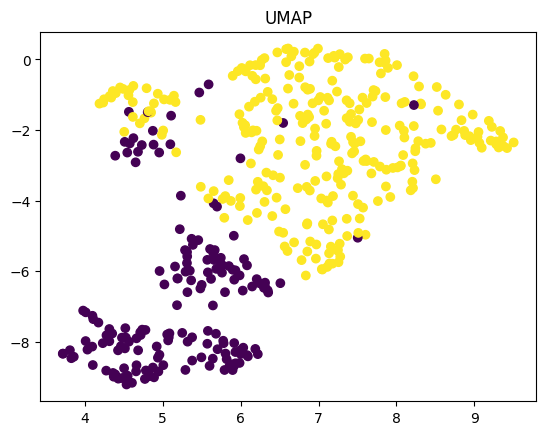

In [10]:

umap_model = umap.UMAP()
X_umap = umap_model.fit_transform(X_train)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y_train)
plt.title("UMAP")
plt.show()


## Feature Selection (Filter)

In [11]:

fs = SelectKBest(f_classif, k=10)
X_train_fs = fs.fit_transform(X_train, y_train)
X_test_fs = fs.transform(X_test)

model.fit(X_train_fs, y_train)
filter_acc = model.score(X_test_fs, y_test)
filter_acc


0.956140350877193

## Feature Selection (Wrapper)

In [12]:

rfe = RFE(RandomForestClassifier(), n_features_to_select=10)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

model.fit(X_train_rfe, y_train)
wrapper_acc = model.score(X_test_rfe, y_test)
wrapper_acc


0.956140350877193

## Performance Comparison

In [13]:

results = pd.DataFrame({
    "Method": ["Baseline", "Filter", "Wrapper"],
    "Accuracy": [baseline_acc, filter_acc, wrapper_acc]
})
results


,Method,Accuracy
0,Baseline,0.964912
1,Filter,0.956140
2,Wrapper,0.956140


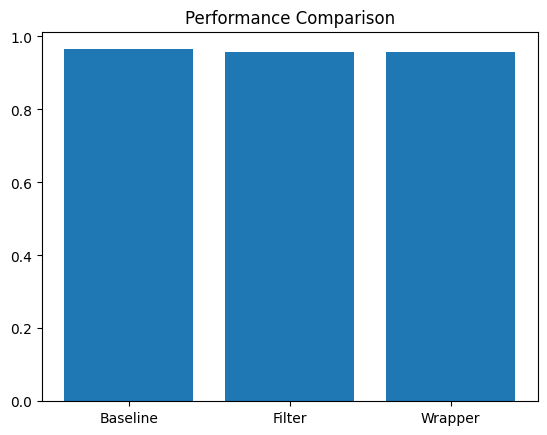

In [14]:

plt.figure()
plt.bar(results["Method"], results["Accuracy"])
plt.title("Performance Comparison")
plt.show()


## Confusion Matrix

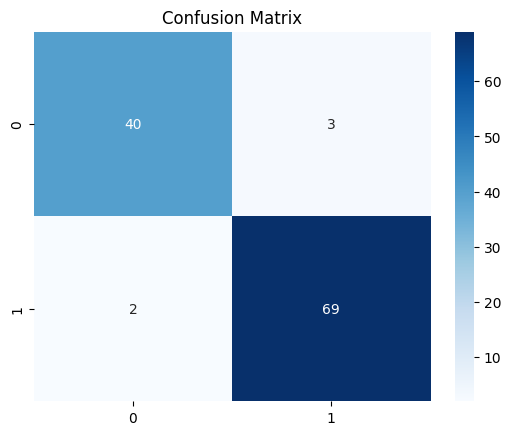

In [15]:

y_pred = model.predict(X_test_rfe)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


## ROC Curve

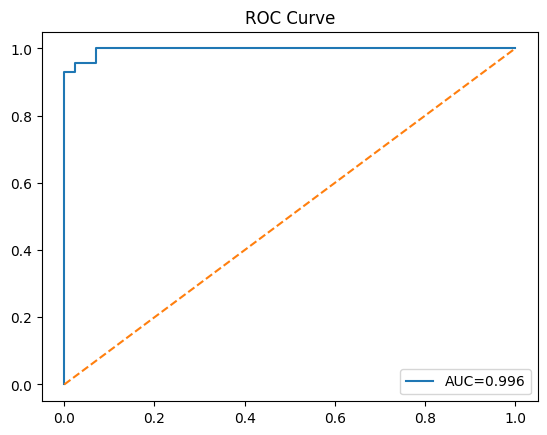

In [16]:

y_prob = model.predict_proba(X_test_rfe)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC="+str(round(roc_auc,3)))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()


## Feature Importance

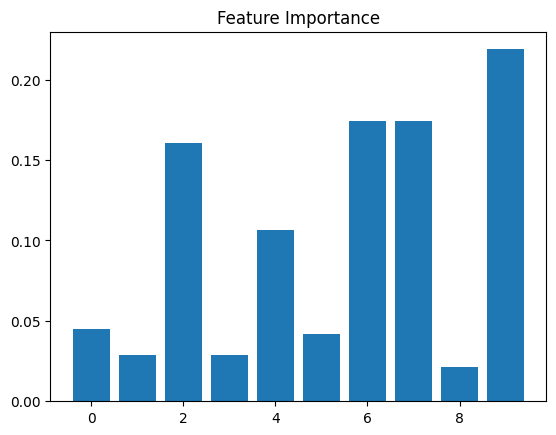

In [17]:

importances = model.feature_importances_

plt.figure()
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()


## Conclusion
This study explored how dimensionality reduction and feature selection influence model performance. The SVM model's results improved after scaling, emphasizing its sensitivity to feature magnitudes. PCA successfully reduced dimensionality while preserving important variance, which improved efficiency. Techniques like RFE enhanced the model's performance by removing irrelevant features. Overall, combining these methods results in a more robust and efficient machine learning model.